# Cantera

In [1]:
import cantera as ct

gas = ct.Solution('gri30.yaml')

print(f"{'ID':<5} | {'Reaction Equation'}")
print("-" * 30)

# Print the first 20 reactions as an example
for i in range(20):
    rxn = gas.reaction(i)
    print(f"{i:<5} | {rxn.equation}")

print(f"\n... plus {gas.n_reactions - 20} more reactions.")

ID    | Reaction Equation
------------------------------
0     | 2 O + M <=> O2 + M
1     | H + O + M <=> OH + M
2     | H2 + O <=> H + OH
3     | HO2 + O <=> O2 + OH
4     | H2O2 + O <=> HO2 + OH
5     | CH + O <=> CO + H
6     | CH2 + O <=> H + HCO
7     | CH2(S) + O <=> CO + H2
8     | CH2(S) + O <=> H + HCO
9     | CH3 + O <=> CH2O + H
10    | CH4 + O <=> CH3 + OH
11    | CO + O (+M) <=> CO2 (+M)
12    | HCO + O <=> CO + OH
13    | HCO + O <=> CO2 + H
14    | CH2O + O <=> HCO + OH
15    | CH2OH + O <=> CH2O + OH
16    | CH3O + O <=> CH2O + OH
17    | CH3OH + O <=> CH2OH + OH
18    | CH3OH + O <=> CH3O + OH
19    | C2H + O <=> CH + CO

... plus 305 more reactions.


In [2]:
pip install cantera

In [3]:
print(f"{'ID':<5} | {'Reaction Equation'}")
print("-" * 30)

for i in range(gas.n_reactions):
    rxn = gas.reaction(i)
    print(f"{i:<5} | {rxn.equation}")

ID    | Reaction Equation
------------------------------
0     | 2 O + M <=> O2 + M
1     | H + O + M <=> OH + M
2     | H2 + O <=> H + OH
3     | HO2 + O <=> O2 + OH
4     | H2O2 + O <=> HO2 + OH
5     | CH + O <=> CO + H
6     | CH2 + O <=> H + HCO
7     | CH2(S) + O <=> CO + H2
8     | CH2(S) + O <=> H + HCO
9     | CH3 + O <=> CH2O + H
10    | CH4 + O <=> CH3 + OH
11    | CO + O (+M) <=> CO2 (+M)
12    | HCO + O <=> CO + OH
13    | HCO + O <=> CO2 + H
14    | CH2O + O <=> HCO + OH
15    | CH2OH + O <=> CH2O + OH
16    | CH3O + O <=> CH2O + OH
17    | CH3OH + O <=> CH2OH + OH
18    | CH3OH + O <=> CH3O + OH
19    | C2H + O <=> CH + CO
20    | C2H2 + O <=> H + HCCO
21    | C2H2 + O <=> C2H + OH
22    | C2H2 + O <=> CH2 + CO
23    | C2H3 + O <=> CH2CO + H
24    | C2H4 + O <=> CH3 + HCO
25    | C2H5 + O <=> CH2O + CH3
26    | C2H6 + O <=> C2H5 + OH
27    | HCCO + O <=> 2 CO + H
28    | CH2CO + O <=> HCCO + OH
29    | CH2CO + O <=> CH2 + CO2
30    | CO + O2 <=> CO2 + O
31    | CH2O + O2

In [4]:
print(f"{'ID':<5} | {'Reaction Equation'}")
print("-" * 60)

count = 0
for i in range(gas.n_reactions):
    rxn = gas.reaction(i)
    # Check if H2 is in reactants or products
    if 'H2' in rxn.reactants or 'H2' in rxn.products:
        print(f"{i:<5} | {rxn.equation}")
        count += 1

print("-" * 60)
print(f"Total reactions involving H2: {count}")

ID    | Reaction Equation
------------------------------------------------------------
2     | H2 + O <=> H + OH
7     | CH2(S) + O <=> CO + H2
38    | 2 H + M <=> H2 + M
39    | 2 H + H2 <=> H2 + H2
40    | 2 H + H2O <=> H2 + H2O
41    | 2 H + CO2 <=> H2 + CO2
44    | H + HO2 <=> H2 + O2
46    | H + H2O2 <=> H2 + HO2
48    | CH + H <=> C + H2
50    | CH2(S) + H <=> CH + H2
52    | CH4 + H <=> CH3 + H2
54    | H + HCO <=> CO + H2
57    | CH2O + H <=> H2 + HCO
59    | CH2OH + H <=> CH2O + H2
64    | CH3O + H <=> CH2O + H2
67    | CH3OH + H <=> CH2OH + H2
68    | CH3OH + H <=> CH3O + H2
72    | C2H3 + H <=> C2H2 + H2
74    | C2H4 + H <=> C2H3 + H2
76    | C2H5 + H <=> C2H4 + H2
77    | C2H6 + H <=> C2H5 + H2
79    | CH2CO + H <=> H2 + HCCO
82    | CO + H2 (+M) <=> CH2O (+M)
83    | H2 + OH <=> H + H2O
125   | CH + H2 <=> CH2 + H
135   | CH2 + H2 <=> CH3 + H
136   | 2 CH2 <=> C2H2 + H2
145   | CH2(S) + H2 <=> CH3 + H
171   | C2H + H2 <=> C2H2 + H
173   | C2H4 (+M) <=> C2H2 + H2 (+M)
190  

In [5]:
# List to store relevant equations
haber_bosch_equations = []

# Define allowed elements for Haber-Bosch (Nitrogen and Hydrogen)
allowed_elements = {'N', 'H'}

# Identify all species in the mechanism that contain forbidden elements
disallowed_species = set()
for sp in gas.species():
    if any(el not in allowed_elements for el in sp.composition):
        disallowed_species.add(sp.name)

print(f"{'ID':<5} | {'Reaction Equation'}")
print("-" * 60)

for i, rxn in enumerate(gas.reactions()):
    # Check 1: Reactants and Products
    involved_species = set(rxn.reactants.keys()) | set(rxn.products.keys())

    # Check 2: Efficiencies (if applicable)
    if hasattr(rxn, 'efficiencies'):
        involved_species.update(rxn.efficiencies.keys())

    # Check 3: Equation String (Robust check for explicit third bodies like H2O)
    # Tokenize equation by replacing symbols with spaces
    eq_tokens = set(rxn.equation.replace('+', ' ').replace('<=>', ' ').replace('=>', ' ').split())

    # Combine all checking methods
    # If any involved species or equation token is in the disallowed list, skip
    if not involved_species.isdisjoint(disallowed_species) or not eq_tokens.isdisjoint(disallowed_species):
        continue

    # If we passed all checks, it's a pure N-H reaction
    haber_bosch_equations.append(rxn.equation)
    print(f"{i:<5} | {rxn.equation}")

print("-" * 60)
print(f"Found {len(haber_bosch_equations)} gas-phase reactions in the pure N-H system.")

ID    | Reaction Equation
------------------------------------------------------------
38    | 2 H + M <=> H2 + M
39    | 2 H + H2 <=> H2 + H2
190   | H + NH <=> H2 + N
195   | N + NH <=> H + N2
201   | H + NH2 <=> H2 + NH
203   | NNH <=> H + N2
204   | NNH + M <=> H + N2 + M
208   | H + NNH <=> H2 + N2
276   | H + NH3 <=> H2 + NH2
------------------------------------------------------------
Found 9 gas-phase reactions in the pure N-H system.


In [6]:
from pyomo.environ import *

model = ConcreteModel()

# --- Parameters (Average values for 20-100 C range) ---
# Enthalpies of formation at 298.15 K (kJ/mol)
# Using LHV (gas phase) for Water
hf_h2 = 0.0
hf_o2 = 0.0
hf_h2o = -241.82

# Constant Molar Heat Capacities (J/mol-K)
cp_h2 = 28.85
cp_o2 = 29.45
cp_h2o = 33.80

# --- Variables ---
model.T_react = Var(initialize=293.15) # 20 C in Kelvin
model.T_prod = Var(initialize=373.15)  # 100 C in Kelvin

# --- Enthalpy Expressions (Linear) ---
# H(T) = Hf + Cp * (T - 298.15)
# Dividing Cp by 1000 to keep units in kJ/mol

def h_reactants_rule(m):
    # For 1 mol H2 and 0.5 mol O2
    h_h2 = hf_h2 + (cp_h2 / 1000.0) * (m.T_react - 298.15)
    h_o2 = hf_o2 + (cp_o2 / 1000.0) * (m.T_react - 298.15)
    return h_h2 + 0.5 * h_o2

def h_products_rule(m):
    # For 1 mol H2O
    return hf_h2o + (cp_h2o / 1000.0) * (m.T_prod - 298.15)

model.H_react = Expression(rule=h_reactants_rule)
model.H_prod = Expression(rule=h_products_rule)

# --- Heat of Reaction Calculation ---
def net_heat_rule(m):
    return m.H_prod - m.H_react

model.DeltaH = Expression(rule=net_heat_rule)

# --- Test Output ---
# You can use a dummy constraint or just print the results
print(f"Reactant Enthalpy (20 C): {value(model.H_react):.4f} kJ")
print(f"Product Enthalpy (100 C): {value(model.H_prod):.4f} kJ")
print(f"Total Heat Exchanged: {value(model.DeltaH):.4f} kJ")

Reactant Enthalpy (20 C): -0.2179 kJ
Product Enthalpy (100 C): -239.2850 kJ
Total Heat Exchanged: -239.0671 kJ


In [7]:

import cantera as ct

def calculate_combustion_heat(T_react_C, T_prod_C, pressure_atm=1.0):
    """
    Calculates the heat of combustion for 1 mole of H2.
    Reactants: H2 + 0.5 O2
    Products: H2O (gas)
    """
    # Load the mechanism
    gas = ct.Solution('gri30.yaml')
    P = pressure_atm * ct.one_atm

    # 1. Define Reactant State
    T_react_K = T_react_C + 273.15
    gas.TPX = T_react_K, P, 'H2:1.0, O2:0.5'
    # Molar enthalpy of the reactant mixture (J/kmol)
    h_reactants = gas.enthalpy_mole

    # 2. Define Product State
    T_prod_K = T_prod_C + 273.15
    gas.TPX = T_prod_K, P, 'H2O:1.0'
    # Molar enthalpy of the product (J/kmol)
    h_products = gas.enthalpy_mole

    # 3. Calculate Delta H (Total Heat Exchanged)
    # Result in kJ per mole of H2
    delta_h = (h_products - h_reactants) / 1e6

    return delta_h

# --- Example Usage ---
t_in = 25   # Reactants at 20 C
t_out = 25 # Products at 100 C

q_net = calculate_combustion_heat(t_in, t_out)

print(f"Inputs: Reactants @ {t_in}°C, Products @ {t_out}°C")
print(f"Net Heat of Reaction: {q_net:.2f} kJ/mol")

Inputs: Reactants @ 25°C, Products @ 25°C
Net Heat of Reaction: -241.82 kJ/mol


In [8]:
pip install CoolProp

In [9]:
import CoolProp
from CoolProp.CoolProp import PropsSI

# Get Enthalpy of Saturated Liquid water at 25C
h_liquid = PropsSI('H', 'T', 298.15, 'Q', 0, 'Water')

# Get Enthalpy of Saturated Gaseous water at 25C
h_gas = PropsSI('H', 'T', 298.15, 'Q', 1, 'Water')

In [10]:
latent_heat_H20 = (h_gas - h_liquid) / 1000 # Convert J/kg to kJ/kg
print(f"Latent heat of water at 25°C and 1 atm is: {latent_heat_H20:.2f} kJ/kg")

Latent heat of water at 25°C and 1 atm is: 2441.68 kJ/kg


In [11]:
import cantera as ct

# Re-initialize gas object if it's not in the kernel or to ensure correct state
# (though it should be from previous cells)
gas = ct.Solution('gri30.yaml')

# Get the molecular weight of water in kg/kmol (which is g/mol)
molar_mass_h2o_g_per_mol = gas.molecular_weights[gas.species_index('H2O')]
molar_mass_h2o_kg_per_mol = molar_mass_h2o_g_per_mol / 1000

# Convert latent heat from kJ/kg to kJ/mol
latent_heat_H2O_kj_per_mol = latent_heat_H20 * molar_mass_h2o_kg_per_mol

print(f"Molar mass of H2O: {molar_mass_h2o_g_per_mol:.2f} g/mol")
print(f"Latent heat of water at 25°C and 1 atm is: {latent_heat_H2O_kj_per_mol:.2f} kJ/mol")

Molar mass of H2O: 18.02 g/mol
Latent heat of water at 25°C and 1 atm is: 43.99 kJ/mol


## Haber-Bosch process

In [12]:
import cantera as ct

def calculate_haber_bosch_heat(T_react_C, T_prod_C):
    gas = ct.Solution('gri30.yaml')
    P = 200 * ct.one_atm  # Typical Haber-Bosch Pressure

    # 1. Reactant Stream 1: Pure N2
    gas.TPX = T_react_C + 273.15, P, 'N2:1.0'
    h_n2 = gas.enthalpy_mole # J/kmol

    # 2. Reactant Stream 2: Pure H2
    gas.TPX = T_react_C + 273.15, P, 'H2:1.0'
    h_h2 = gas.enthalpy_mole # J/kmol

    # Total Enthalpy of Reactants (1 mol N2 + 3 mol H2)
    H_reactants_total = 1.0 * h_n2 + 3.0 * h_h2

    # 3. Product Stream: Pure NH3
    gas.TPX = T_prod_C + 273.15, P, 'NH3:1.0'
    h_nh3 = gas.enthalpy_mole # J/kmol

    # Total Enthalpy of Products (2 mol NH3)
    H_products_total = 2.0 * h_nh3

    # Delta H in kJ per mole of N2 consumed
    return (H_products_total - H_reactants_total) / 1e6

# Scenario: Reactants pre-heated to 300C, Products exit at 450C
q_net = calculate_haber_bosch_heat(300, 450)
print(f"Net Heat of Haber-Bosch Process (Separate Streams): {q_net:.2f} kJ per mol of N2")

Net Heat of Haber-Bosch Process (Separate Streams): -88.01 kJ per mol of N2


In [13]:
import cantera as ct

def calculate_ammonia_cracking_heat(T_react_C, T_prod_C):
    # Reverse of Haber-Bosch: 2 NH3 -> 1 N2 + 3 H2
    gas = ct.Solution('gri30.yaml')
    P = 1 * ct.one_atm # Cracking often done at lower pressures, using 1 atm for reference

    # 1. Reactant Stream: Pure NH3
    # Stoichiometry: 2 moles of NH3
    gas.TPX = T_react_C + 273.15, P, 'NH3:1.0'
    h_reactants = gas.enthalpy_mole * 2.0

    # 2. Product Stream 1: Pure N2 (1 mole)
    gas.TPX = T_prod_C + 273.15, P, 'N2:1.0'
    h_n2 = gas.enthalpy_mole * 1.0

    # 3. Product Stream 2: Pure H2 (3 moles)
    gas.TPX = T_prod_C + 273.15, P, 'H2:1.0'
    h_h2 = gas.enthalpy_mole * 3.0

    # Total Enthalpy of Products
    H_products_total = h_n2 + h_h2

    # Delta H in kJ per mole of N2 produced
    return (H_products_total - h_reactants) / 1e6

# 1. Standard Chemical Energy (Bond Energy difference) at 25 C
q_standard = calculate_ammonia_cracking_heat(25, 25)
print(f"Standard Heat of Reaction (25°C): {q_standard:.2f} kJ per mol of N2 produced")

# 2. Process Scenario: NH3 enters at 300C, Products exit at 450C
q_process = calculate_ammonia_cracking_heat(300, 450)
print(f"Process Heat (NH3@300C -> N2+H2@450C): {q_process:.2f} kJ per mol of N2 produced")

Standard Heat of Reaction (25°C): 91.80 kJ per mol of N2 produced
Process Heat (NH3@300C -> N2+H2@450C): 119.80 kJ per mol of N2 produced


# Thermo

In [14]:
pip install thermo

In [15]:
from thermo import Chemical

# Initialize the chemical
nh3 = Chemical('ammonia', T=723.15, P=200e5) # 450C and 200 bar

# Print a few key "Real" properties
print(f"Molar Volume: {nh3.Vmg:.6f} m^3/mol") # Real volume at high P
print(f"Dynamic Viscosity: {nh3.mug:.6e} Pa*s")
print(f"Thermal Conductivity: {nh3.kg:.4f} W/m/K")

# Molar Mass
print(f"Molar Mass: {nh3.MW:.4f} g/mol")

Molar Volume: 0.000301 m^3/mol
Dynamic Viscosity: 2.568959e-05 Pa*s
Thermal Conductivity: 0.0926 W/m/K
Molar Mass: 17.0305 g/mol


Calculating Cp values... (Pressure = 1 atm)


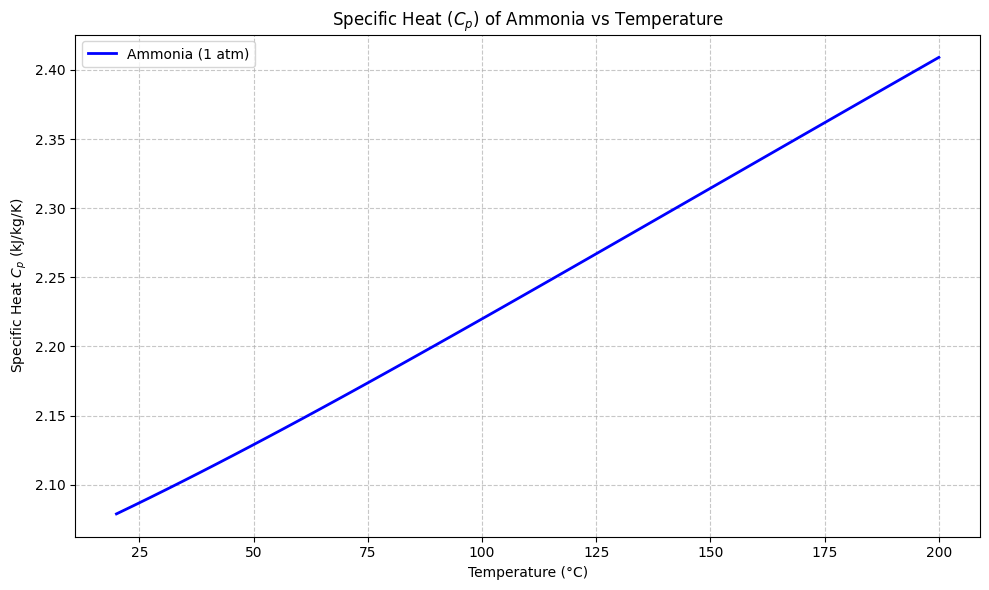

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from thermo import Chemical

# Define temperature range: 20°C to 200°C
T_celsius = np.linspace(20, 200, 50)
T_kelvin = T_celsius + 273.15

cp_values = []

print("Calculating Cp values... (Pressure = 1 atm)")

for T in T_kelvin:
    # Initialize Ammonia at current T and 1 atm (101325 Pa)
    nh3 = Chemical('ammonia', T=T, P=101325)

    # nh3.Cp in this library returns Specific Heat Capacity (J/kg/K)
    # We just need to convert to kJ/kg/K
    cp_mass_j = nh3.Cp
    cp_mass_kj = cp_mass_j / 1000.0
    cp_values.append(cp_mass_kj)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(T_celsius, cp_values, '-b', linewidth=2, label='Ammonia (1 atm)')

plt.title('Specific Heat ($C_p$) of Ammonia vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Specific Heat $C_p$ (kJ/kg/K)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
from thermo import Chemical

# Define conditions
T = 298.15 # 25 C
P = 101325

# 1. Air (Approximated as Nitrogen)
air_proxy = Chemical('Nitrogen', T=T, P=P)

# 2. Ammonia
nh3 = Chemical('Ammonia', T=T, P=P)

print(f"--- Corrected Comparison at 25°C ---")

# Molar Mass Comparison
print(f"Molar Mass (Air/N2): {air_proxy.MW:.2f} g/mol")
print(f"Molar Mass (Ammonia): {nh3.MW:.2f} g/mol")
print(f"-> Ammonia is lighter by factor: {air_proxy.MW / nh3.MW:.2f}x")
print("")

# Specific Heat Capacity (J/kg/K) - The library returns this directly in .Cp
cp_air_spec = air_proxy.Cp / 1000.0 # Convert J/kg/K to kJ/kg/K
cp_nh3_spec = nh3.Cp / 1000.0      # Convert J/kg/K to kJ/kg/K

print(f"Specific Cp (Air/N2): {cp_air_spec:.2f} kJ/kg/K")
print(f"Specific Cp (Ammonia): {cp_nh3_spec:.2f} kJ/kg/K")
print(f"-> Ammonia has {cp_nh3_spec / cp_air_spec:.2f}x higher heat capacity per kg")
print("")

# Molar Heat Capacity (J/mol/K) - Calculated from Specific
# Cp_molar = Cp_specific (J/kg/K) * MW (kg/mol)
cp_air_molar = air_proxy.Cp * (air_proxy.MW / 1000.0)
cp_nh3_molar = nh3.Cp * (nh3.MW / 1000.0)

print(f"Molar Cp (Air/N2): {cp_air_molar:.2f} J/mol/K")
print(f"Molar Cp (Ammonia): {cp_nh3_molar:.2f} J/mol/K")
print(f"-> Per molecule, Ammonia stores {cp_nh3_molar / cp_air_molar:.2f}x more energy")

--- Corrected Comparison at 25°C ---
Molar Mass (Air/N2): 28.01 g/mol
Molar Mass (Ammonia): 17.03 g/mol
-> Ammonia is lighter by factor: 1.64x

Specific Cp (Air/N2): 1.04 kJ/kg/K
Specific Cp (Ammonia): 2.09 kJ/kg/K
-> Ammonia has 2.01x higher heat capacity per kg

Molar Cp (Air/N2): 29.13 J/mol/K
Molar Cp (Ammonia): 35.54 J/mol/K
-> Per molecule, Ammonia stores 1.22x more energy


# NIST Database

In [ ]:
pip install chempy

In [ ]:
from chempy import Substance

# Chempy uses local databases often derived from NIST/JANAF
H2 = Substance.from_formula('H2')
print(H2.molar_mass())

In [ ]:
import CoolProp
from CoolProp.CoolProp import PropsSI

# Define State
T_C = 200
T_K = T_C + 273.15
P_Pa = 101325 # 1 atm

# Calculate Specific Heat (Cp) using CoolProp (NIST EOS)
# 'C' in CoolProp stands for Mass Specific Heat (Cp) in J/kg/K
cp_h2_j_kg_k = PropsSI('C', 'T', T_K, 'P', P_Pa, 'Hydrogen')

# Convert to kJ/kg/K
cp_h2_kj_kg_k = cp_h2_j_kg_k / 1000.0

print(f"--- Hydrogen (H2) at {T_C}°C and 1 atm ---")
print(f"Specific Heat (Cp): {cp_h2_j_kg_k:.2f} J/kg/K")
print(f"Specific Heat (Cp): {cp_h2_kj_kg_k:.2f} kJ/kg/K")

In [ ]:
# Calculate Specific Heat (Cp) for Water Vapor at 200°C
# 200°C is > 100°C, so at 1 atm it is a gas (Superheated Vapor)

cp_h2o_j_kg_k = PropsSI('C', 'T', T_K, 'P', P_Pa, 'Water')

# Convert to kJ/kg/K
cp_h2o_kj_kg_k = cp_h2o_j_kg_k / 1000.0

print(f"--- Water Vapor (H2O) at {T_C}°C and 1 atm ---")
print(f"Specific Heat (Cp): {cp_h2o_j_kg_k:.2f} J/kg/K")
print(f"Specific Heat (Cp): {cp_h2o_kj_kg_k:.2f} kJ/kg/K")

In [ ]:
# Constants
MW_H2 = 2.016   # g/mol
MW_H2O = 18.015 # g/mol

# Specific Heats from previous steps (kJ/kg/K)
Cp_specific_H2 = 14.51
Cp_specific_H2O = 1.98

print("--- Factor 1: Molar Mass (How many molecules per kg?) ---")
print(f"Molar Mass H2:  {MW_H2:.2f} g/mol")
print(f"Molar Mass H2O: {MW_H2O:.2f} g/mol")
ratio_mass = MW_H2O / MW_H2
print(f"-> 1 kg of H2 has {ratio_mass:.2f}x more molecules than 1 kg of H2O")
print("")

print("--- Factor 2: Molar Heat Capacity (Energy stored per MOLECULE) ---")
# Cp_molar = Cp_specific * MW
Cp_molar_H2 = Cp_specific_H2 * MW_H2
Cp_molar_H2O = Cp_specific_H2O * MW_H2O

print(f"Molar Cp H2:  {Cp_molar_H2:.2f} J/mol/K")
print(f"Molar Cp H2O: {Cp_molar_H2O:.2f} J/mol/K")
ratio_molar = Cp_molar_H2O / Cp_molar_H2
print(f"-> Water actually stores {ratio_molar:.2f}x MORE energy per molecule!")
print("")

print("--- Conclusion ---")
print(f"Total Difference = (More Molecules) / (Energy per Molecule)")
print(f"Predicted Ratio: {ratio_mass:.2f} / {ratio_molar:.2f} = {ratio_mass/ratio_molar:.2f}x")
print(f"Actual Ratio:    {Cp_specific_H2:.2f} / {Cp_specific_H2O:.2f} = {Cp_specific_H2/Cp_specific_H2O:.2f}x")